# The Complete Training Loop

## Help a machine follow a curved path

Imagine a toy sensor sliding along a track. At some positions its reading is low; at others it is high. We have a collection of positions paired with readings. We want a small neural network to predict a reading at a new position.

The network begins with adjustable **parameters**: weights that multiply values and biases that add offsets. We start them with random values rather than the unknown best settings. The first predictions therefore have no reason to trace our sensor's curve well.

A **training loop** repeats a connected set of actions: make predictions, measure their mistakes, calculate how parameters affect those mistakes, and change the parameters a little.

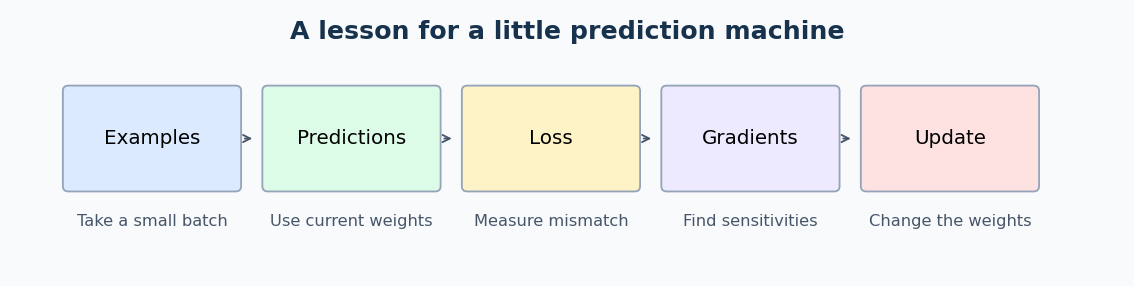

After an update, the same network can produce different answers. The purpose of repeating the cycle is to find parameters that capture a useful pattern rather than merely remember individual readings.

The [code companion](09_The_Complete_Training_Loop.ipynb) runs this experiment on CPU using a small dataset generated locally. These notes explain the same experiment independently, including how we decide which model to keep and what its result does—and does not—show.

## Start with the problem this lesson solves

One successful update is not a trained model. A training loop must repeatedly present examples, calculate mistakes, change parameters, and check whether progress extends to examples that were not used for updates.

The ANN's job in this lesson is to predict a sensor reading from position. Its nonlinear hidden layers can represent a curved relationship. The loop coordinates learning; it does not create representational ability that the chosen architecture lacks.

## Make every operation in one batch concrete

Before the larger nonlinear sensor model, inspect a separate two-example miniature. Use predictor $\hat y=wx+b$, starting $w=0,b=0$, inputs $[1,2]$, and targets $[2,4]$. This one-neuron example uses plain SGD so no optimizer state obscures the arithmetic.

**Forward:** predictions are $[0(1)+0,0(2)+0]=[0,0]$.

**Loss:** errors are $[-2,-4]$; squared errors are $[4,16]$; their mean is $L=(4+16)/2=10$.

**Backward:** for a mean of two squared errors, each prediction's derivative is $2(\hat y_i-y_i)/2$, giving $[-2,-4]$. A weight affects the prediction by multiplying its input, so

$$\frac{\partial L}{\partial w}=(-2)(1)+(-4)(2)=-10.$$

A bias adds one unit to each prediction per unit change, so $\partial L/\partial b=-2-4=-6$.

**Step:** at rate $0.1$, $w'=0-0.1(-10)=1$ and $b'=0-0.1(-6)=0.6$.

**Recompute:** predictions are $[1(1)+0.6,1(2)+0.6]=[1.6,2.6]$. Errors are $[-0.4,-1.4]$, so loss is $(0.16+1.96)/2=1.06$. This batch improved, but the true relation $y=2x$ has not yet been recovered.

**Check a validation example without learning from it:** if a held-out input is $1.5$ with target three, the updated prediction is $1(1.5)+0.6=2.1$ and its squared error is $0.81$. We record this score; we do not backpropagate it. Repeated validation helps choose a checkpoint, so a separate test set is needed for the final evaluation.

**Repeat with the right bookkeeping:** before the next batch, clear old gradients so its update uses its own intended loss. An epoch means one pass through the training data. In the actual companion, 120 training examples divided into batches of 24 give five updates per epoch; 150 epochs give $5\times150=750$ updates. That larger model uses Adam and a nonlinear sensor task, so it is not expected to reproduce this miniature's weights.

## Why each part of the loop has a separate job

Training examples determine gradient updates. Validation examples select settings or saved states. Test examples estimate performance after those choices are fixed. Shuffling changes which examples meet in a batch; it does not change their labels. Saving the best validation state protects against assuming that the final epoch is necessarily best.

`train()` and `eval()` control behavior of layers such as dropout; they do not themselves enable or disable all gradient tracking. A no-gradient context avoids building an unnecessary backward graph during evaluation. The trained model helps by predicting the sensor curve on new positions, which must be checked against a simple baseline.

## Build a small world whose pattern we can see

Let $x$ be a position between minus one and one. We generate a clean reading with:

$$f(x)=0.5\sin(\pi x)+0.3x.$$

$f$ names our rule. The sine function, $\sin$, makes a smooth wave, and $\pi$ is the constant approximately $3.14159$. Multiplying the wave by $0.5$ controls its height. Adding $0.3x$ gives the reading a gentle upward tilt as the position increases.

| Position $x$ | Wave term $0.5\sin(\pi x)$ | Tilt $0.3x$ | Clean reading |
| --- | --- | --- | --- |
| -0.5 | -0.5 | -0.15 | -0.65 |
| 0 | 0 | 0 | 0 |
| 0.5 | 0.5 | 0.15 | 0.65 |

Real measurements rarely sit perfectly on a rule. We therefore add a small random amount called **noise** to each generated reading. The noise is centered on zero, with standard deviation $0.04$, a measure of its typical spread. It can move a reading upward or downward.

The companion generates two hundred position-reading pairs. We know the clean formula because we invented the world. The network is not handed that formula during fitting; it receives only the designated training pairs.

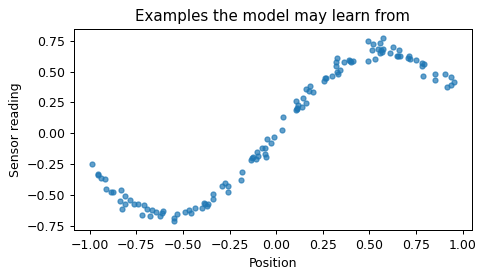

Each dot is one example, not a separate model. The goal is to learn the broad relationship without needing to pass through every noisy dot exactly.

## Give each group of examples one clear job

A model might fit familiar examples very well but perform poorly on new ones. Before fitting, we randomly divide the pairs into three nonoverlapping groups.

| Group | Number of examples | Its job | Does it drive gradient updates? |
| --- | --- | --- | --- |
| Training | 120 | Supply the examples used to change parameters | Yes |
| Validation | 40 | Choose which saved parameter state to keep | No |
| Test | 40 | Evaluate the fixed choice at the end | No |

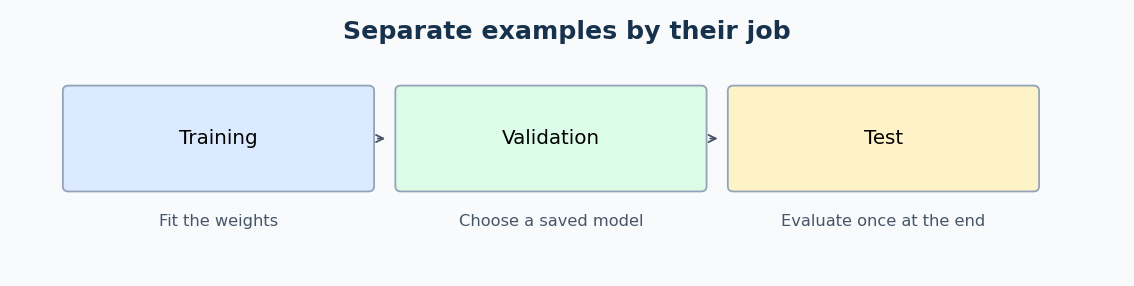

Think of training examples as material used while learning a pattern. Validation is a separate view used to make a model choice. Test is the final comparison after that choice has been made. The arrows show the order of work, not examples moving from group to group.

The companion shuffles example indices and splits them once. Each position stays paired with its own reading, and each example keeps its assigned role.

We use fixed random **seeds**, starting settings for the random-number generators, to make the demonstration repeatable in the stated environment. Seeds do not make the data more representative or the model more accurate. They help us reproduce the same experiment.

Because validation selects the checkpoint, it already influences our choice. Repeatedly looking at test results and changing settings in response would make test data part of that choice too, weakening its value as a final independent comparison.

## Choose a network that can bend its response

A single straight-line rule cannot exactly follow our curved sensor pattern. The companion uses a small network with two hidden layers and a final output layer.

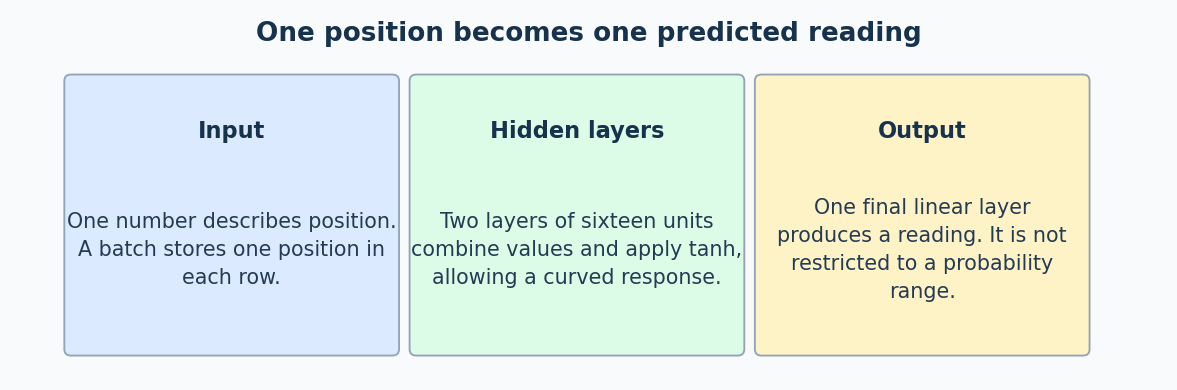

Each **linear layer** forms weighted sums and adds biases. Each hidden layer then applies **tanh**, a smooth function that bends values into the range between minus one and one. These bends let the full network represent a curved relationship. Stacking linear layers without such nonlinear steps would still give an overall straight-line rule.

| Stage | Values in each example | What it does |
| --- | --- | --- |
| Input | One position | Describe where the sensor is |
| First hidden layer | Sixteen values | Combine the position with learned weights and biases, then apply tanh |
| Second hidden layer | Sixteen values | Recombine those hidden values, then apply tanh |
| Output layer | One reading | Combine the final hidden values into an unrestricted prediction |

The output has no sigmoid or tanh after it. Our answer is a numerical sensor reading, not a probability, so we do not need to force it into a probability range.

This model has $32+272+17=321$ parameters: the first layer has sixteen weights and sixteen biases; the second has $16\times16$ weights and sixteen biases; the output has sixteen weights and one bias. It is a small demonstration architecture, not a claim that this size is necessary or best.

## Serve the examples in batches

A **batch** is a group of examples processed together. An **epoch** is one complete pass through the training examples.

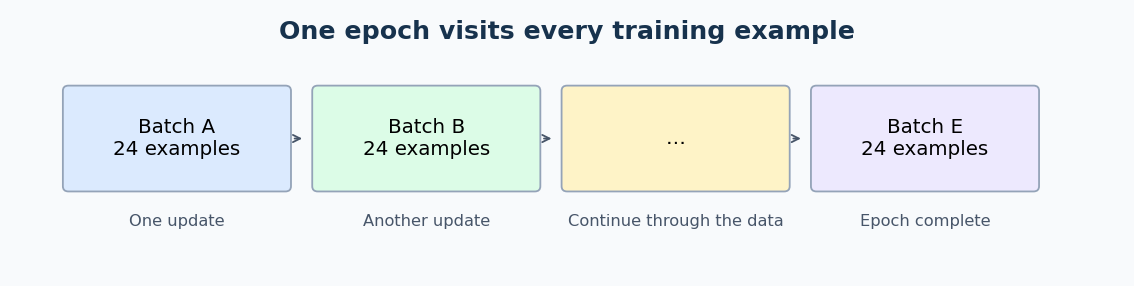

Here each batch contains twenty-four examples. Since $120/24=5$, each epoch contains five batches. We make one parameter update per batch, so one epoch means five updates.

| Term | Meaning in this experiment |
| --- | --- |
| Example | One position and its matching reading |
| Batch | Twenty-four examples processed together |
| Update | One optimizer step after computing a batch gradient |
| Epoch | All five training batches have been visited |

A `TensorDataset` keeps positions and readings paired. A `DataLoader` serves those pairs in batches. It shuffles their order each epoch so the same neighbors do not always arrive together. It does not shuffle positions separately from their readings or move examples into another data group.

The batch input has shape `(24, 1)`: twenty-four rows, one position per row. Predictions and targets have the same shape, with one reading per row. Matching shapes protects the intended comparison between each prediction and its own target.

Batches let several examples contribute to an update without processing the full dataset at once. They also make the gradient vary from batch to batch, because different examples can suggest different changes.

## Turn a batch of mistakes into one loss

A **loss function** converts prediction-target differences into a score. The loop uses **mean squared error**, or MSE: subtract each target, square each difference, and average.

Here is a small illustrative batch so we can see the arithmetic:

| Example | Target | Prediction | Error | Squared error |
| --- | --- | --- | --- | --- |
| A | 0.5 | 0.7 | 0.2 | 0.04 |
| B | -0.1 | -0.5 | -0.4 | 0.16 |

The batch loss is $(0.04+0.16)/2=0.10$. Squaring prevents positive and negative errors from canceling and gives larger misses more emphasis.

The full formula is:

$$L=\frac{1}{B}\sum_{i=1}^{B}(\hat y_i-y_i)^2.$$

$B$ is the batch size. The index $i$ selects an example, $y_i$ is its target, and $\hat y_i$ is its predicted reading. The symbol $\sum$ means add the terms. With one output per example, PyTorch's `MSELoss` averages exactly these terms.

A smaller loss means closer agreement with the supplied targets under this rule. It does not tell us whether the targets are reliable or whether the network will predict unfamiliar examples well. Those are separate questions.

## Follow one batch from prediction to update

A **gradient** measures how loss responds to small changes in parameters. **Backpropagation** calculates those sensitivities by following the recorded operations backward from the loss. An **optimizer** then chooses parameter changes using the gradients.

| Action | What it means | PyTorch expression |
| --- | --- | --- |
| Clear old gradients | Start a fresh batch calculation without old contributions | `optimizer.zero_grad(set_to_none=True)` |
| Predict | Pass the input positions through the current network | `model(batch_x)` |
| Measure loss | Compare the predictions with matching readings | `loss_fn(predictions, batch_y)` |
| Calculate gradients | Find current parameter sensitivities | `loss.backward()` |
| Change parameters | Apply the optimizer's update rule | `optimizer.step()` |

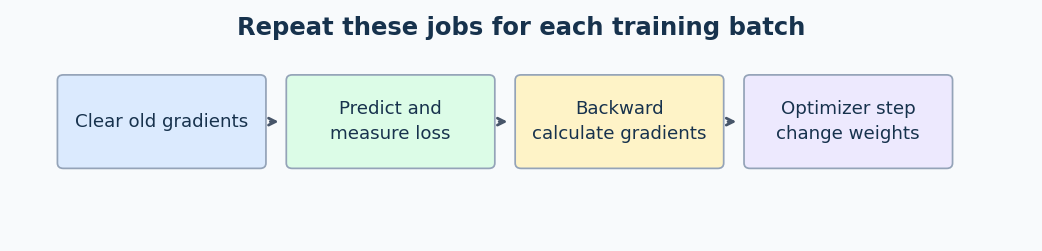

We use **Adam**, an optimizer that keeps running records of gradient directions and squared sizes to scale its updates. The learning rate is $0.01$, controlling the scale of those moves. This is a fixed demonstration setting, not a universal good value.

The optimizer is created once before the repeated loop so its records persist. Clearing gradients removes previous contributions from parameter `.grad` buffers. It does not reset weights or erase Adam's records.

This order matters. Calling backward without clearing old contributions would add them to the current batch's gradients. Calling an optimizer step without a fresh intended gradient could use stale information. A new prediction is also needed after a parameter update because the model has changed.

## Make one update visible before repeating it

Before the full run, the companion makes an independent copy of the starting network and applies one update to that copy. This separates an arithmetic demonstration from the actual training run.

It measures the batch's loss, computes gradients, and verifies that backward left all parameter values unchanged. Only the subsequent optimizer step moves the parameters. It then measures the same batch again to show the effect.

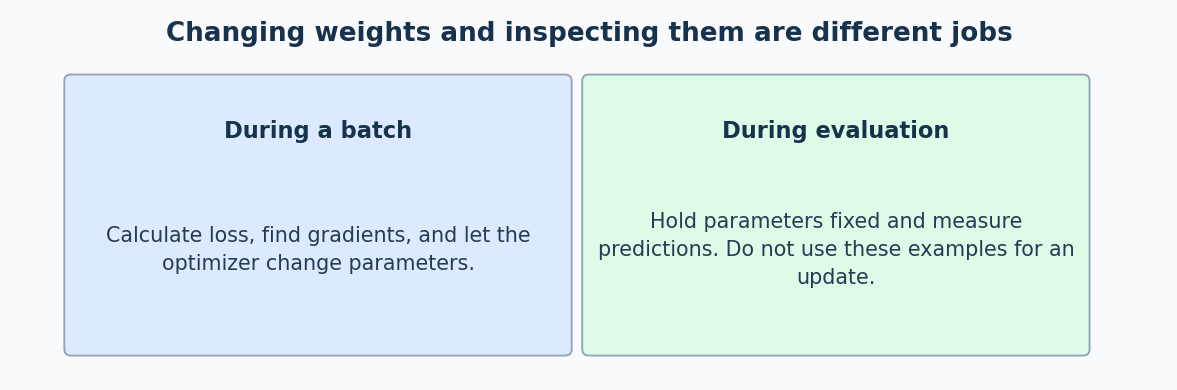

The printed **gradient size** combines all gradient entries by squaring them, adding them, and taking a square root. The printed **parameter movement** does the same for differences between old and new parameter values. They answer different questions: how large was the sensitivity signal, and how far did the update actually move?

The single update may lower that batch's loss, but the loop does not promise improvement after every step. Step size, batch composition, and the loss surface all matter.

The full run starts from the untouched original model. The demonstration copy neither gives it an extra update nor changes the data loader's shuffle sequence.

## Repeat updates, then pause to measure progress

The full run makes a fixed hundred and fifty epochs. With five updates per epoch, that is $150\times5=750$ updates.

After each epoch, the program holds the parameters fixed and measures loss on the complete training and validation groups. This produces two comparable measurements of that single model state.

| PyTorch setting | Its job | A common misunderstanding |
| --- | --- | --- |
| `model.train()` | Select training behavior for layers that distinguish modes | It does not start training or update weights by itself |
| `model.eval()` | Select evaluation behavior for those layers | It does not disable gradient recording |
| `torch.no_grad()` | Avoid recording operations for gradient calculations | It does not switch the model into evaluation mode |

Our linear and tanh layers behave identically in training and evaluation modes. Keeping both mode selection and gradient recording explicit still makes the program's intent clear. Evaluation uses `eval()` together with `no_grad()`, and the next training epoch begins with `train()`.

Why recompute the training loss at the end of an epoch? Batch losses collected during training came from different parameter states: the model changed between batches. Recomputing gives one clean measurement of the model as it exists now.

The program also records the starting losses before any updates. This provides a visible starting point and allows the initial model to be selected if training never improves validation loss.

## Read the two learning curves together

A **learning curve** shows how a measured score changes during training. Here the horizontal axis is epoch and the vertical axis is MSE.

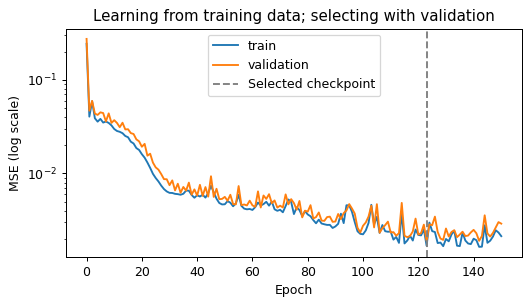

| Pattern | A possible interpretation |
| --- | --- |
| Training and validation loss both fall | Improvements on familiar examples also help held-out validation examples |
| Training loss falls while validation loss rises | The model may be adapting too closely to training-specific details |
| Both losses stay high | The model, settings, data, or calculation may need investigation |
| Small fluctuations | Different batches and updates can make progress uneven |

**Overfitting** means fitting training-specific details in a way that harms performance on other examples. A widening gap can be evidence of it, but one noisy point is not a complete diagnosis. These groups are small, and measurement noise affects their losses.

The plot uses a logarithmic vertical scale so small losses remain visible. Equal vertical distances mean multiplication by the same factor, not subtraction of the same amount. Each point still represents the ordinary MSE value.

The dashed line marks the state selected by validation. Its position need not be the last epoch: additional training does not automatically improve the model we want to keep.

## Save the best validation snapshot

A **checkpoint** is a saved model state. Here we use validation loss to choose which parameter values to save for the final comparison.

After each epoch, compare its validation loss with the lowest one recorded so far. If it is lower, copy the current model state. Otherwise, keep the earlier copy.

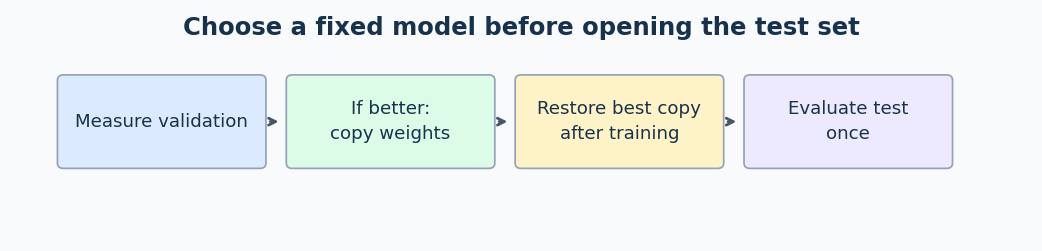

For example, suppose successive validation losses were $0.08$, $0.05$, and $0.06$. The middle state would remain selected after the third measurement, even though the live model has moved on. These values illustrate the rule, not the actual run's measurements.

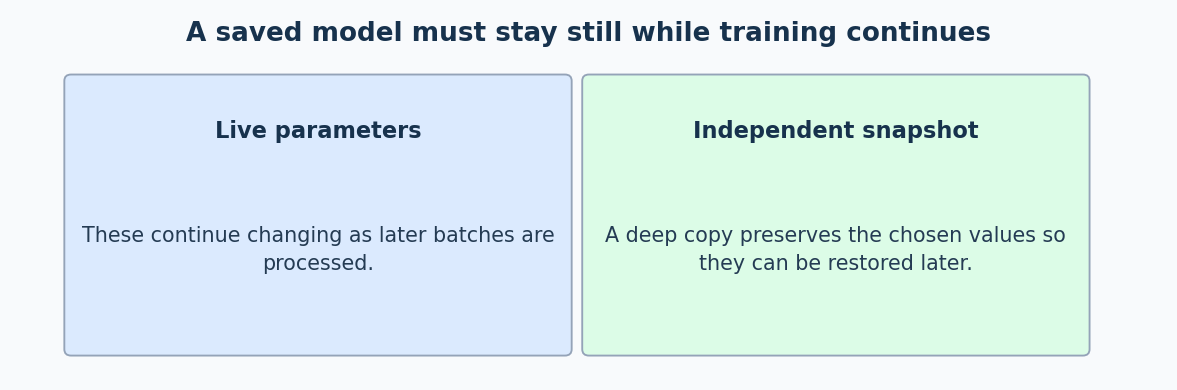

A **deep copy** creates independent stored values. Simply keeping a reference to live tensors could let the supposed snapshot change along with the model. The companion uses `copy.deepcopy(model.state_dict())` to preserve it, then restores the best snapshot with `load_state_dict(...)` after all epochs finish.

This is checkpoint selection under a fixed training budget, not early stopping: the loop still completes its hundred and fifty epochs. In the saved run, validation selects the state from epoch $123$.

The snapshot stays in memory here. For final prediction with this architecture, the selected model state is enough. Faithfully resuming a training run would also need optimizer history and other state such as random-generator and data-order information.

## Compare the fixed choice with a simple baseline

Only after selecting and restoring the model do we open the test group. Test scores report how this fixed choice behaves on new samples from the same simulated process.

A **baseline** is a simple comparison method. Our baseline always predicts the average training reading, no matter the input position. Its prediction is fitted using training data alone; it does not look at test readings to choose its constant.

We also keep the untrained network for comparison. Its predictions reveal how much changed through learning rather than through the architecture alone.

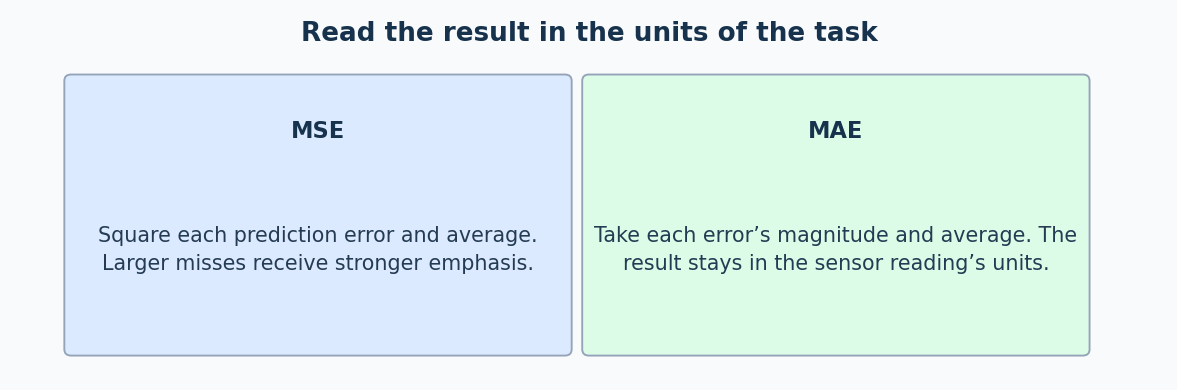

Alongside MSE, we report **mean absolute error**, or MAE. It removes the sign of each error and averages the magnitudes. MAE remains in the original reading units, while MSE is in squared units.

| Fixed model in the saved run | Test MSE | Test MAE |
| --- | --- | --- |
| Training-mean baseline | About 0.285793 | About 0.503849 |
| Selected neural network | About 0.001581 | About 0.030354 |

For this run, the neural network's typical error magnitude is much smaller than the constant baseline's. That is evidence of useful pattern learning on this constructed task. It does not show that a neural network beats every simpler approach; a model designed around a suitable curved formula could also be effective.

These test results do not trigger more tuning in the notebook. Exact reproduced values can depend on the numerical environment; the companion records versions and fixes its random choices.

## Connect the scores to the picture

The companion plots the same architecture before learning and after restoring the selected state. The dots are held-out test readings, the dashed line is the known clean generator, and the colored line is the network's prediction.

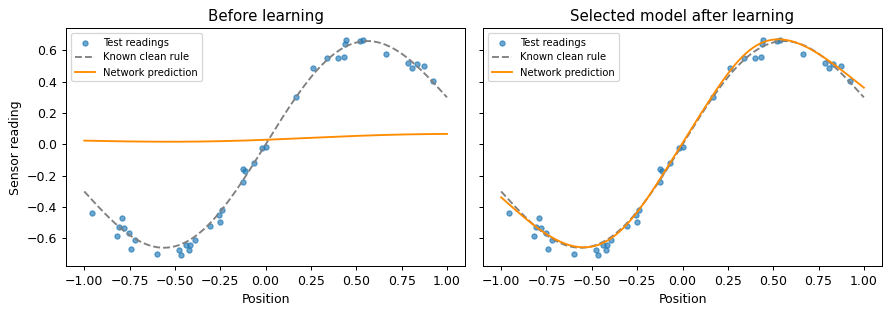

The picture makes the improvement interpretable: the trained network follows the broad curve rather than predicting a nearly constant or unrelated response. Because observations contain noise, a useful prediction need not pass through each dot.

The plotted grid provides positions at which to display predictions. It is not extra training data, and the clean reference curve is not used to select the checkpoint.

We only sampled positions between minus one and one. The graph gives no evidence about reliable behavior beyond that range. Nor does a synthetic sensor establish that real sensors follow this formula or have the same noise.

## Keep the whole loop connected

| Part of the journey | Information it uses | What it produces |
| --- | --- | --- |
| Training batch | Training inputs, targets, and current parameters | Gradients and updated parameters |
| End-of-epoch measurement | Fixed current model and separate data groups | Training and validation losses |
| Checkpoint selection | Validation loss history | An independent copy of the chosen model state |
| Final evaluation | Restored model and untouched test examples | A comparison with the baseline |

The loop connects prediction, loss, gradients, and updates while keeping data roles clear. Each part answers a different question: how should the model change, which state should we keep, and how does that fixed choice perform on new examples?

A program can run without errors and still teach the wrong relationship if examples are mismatched, targets are unreliable, or test results repeatedly guide decisions. Clear pairings, fresh gradients, preserved snapshots, and interpretable comparisons make those mistakes easier to notice.

In this small experiment, the completed loop learns a curved relationship and evaluates it against a simple baseline. Its value is that every stage can be inspected—from the first imperfect guess to the final held-out result.

## Stop when validation stops improving

Training loss measures fit to the examples used for updates; validation loss estimates performance on held-out examples. A practical stopping rule watches validation loss, allows a small tolerance (`min_delta`), and stops after `patience` checks without improvement. Restore the best checkpoint, because the final epoch may already be overfit. Also inspect a maximum epoch limit, a learning-rate schedule, and whether the metric has genuinely plateaued rather than merely fluctuating.

Regularization changes the objective or the training procedure. **L1** adds $\lambda\sum_j|w_j|$, encouraging some weights toward exactly zero and therefore sparse solutions. **L2** adds $\lambda\sum_jw_j^2$ and usually shrinks weights smoothly. The penalty must be applied to the intended parameters, not accidentally to biases or normalization parameters. Dropout randomly zeros training activations and scales survivors; evaluation disables the random mask. Early stopping is a validation-based control on training duration, not a substitute for a test set.

The companion cell demonstrates patience and compares an unregularized model, L1, and dropout on a small noisy regression problem. The purpose is to make the mechanisms visible; the best strength is still selected with validation evidence.